In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score ,roc_curve, auc

In [2]:
df = pd.read_csv("Customer churn kaggle data.csv")
df = df.drop('customerID', axis = 1)

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df = df.dropna()

In [4]:
df['Churn'] = df['Churn'].map({"Yes": 1, "No": 0})
df = pd.get_dummies(df, drop_first = True)

In [36]:
x = df.drop('Churn', axis = 1)
y = df['Churn']
df['Churn'].value_counts()

0    5163
1    1869
Name: Churn, dtype: int64

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [31]:
model = XGBClassifier(
    n_estimators = 200,
    max_depth = 5,
    learning_rate = 0.1,
    use_label_encoder = False,
    eval_metric = 'logloss',
    scale_pos_weight = 5163/1869 # Since data is imbalanced so pay more attention to minority class that is class 1(churn) 
)
model.fit(x_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.1, max_delta_step=0,
              max_depth=5, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=200, n_jobs=8,
              num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=2.7624398073836276,
              subsample=1, tree_method='exact', use_label_encoder=False,
              validate_parameters=1, verbosity=None)

In [39]:
y_prob = model.predict_proba(x_test)[:,1]
y_pred = (y_prob>0.3).astype(int)
print(confusion_matrix(y_test, y_pred))

[[636 397]
 [ 47 327]]


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.62      0.74      1033
           1       0.45      0.87      0.60       374

    accuracy                           0.68      1407
   macro avg       0.69      0.75      0.67      1407
weighted avg       0.80      0.68      0.70      1407



In [41]:
import matplotlib.pyplot as plt
import numpy as np

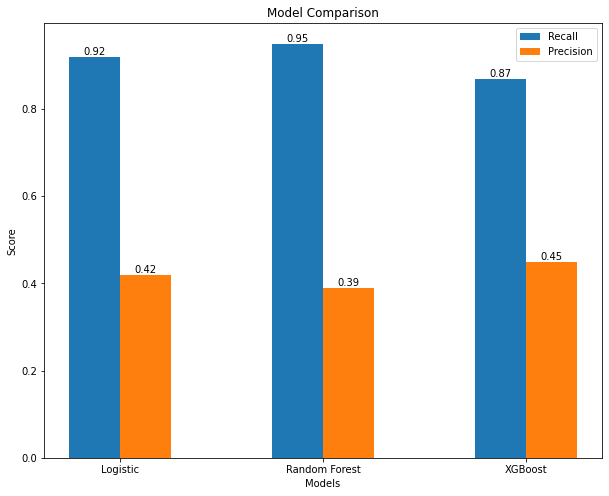

In [97]:
models = ["Logistic", "Random Forest", "XGBoost"]
recall = [0.92, 0.95, 0.87]
precision = [0.42, 0.39, 0.45]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,8))
bar1 = plt.bar(x-width/2, recall, width, label = "Recall")
bar2 = plt.bar(x+width/2, precision, width, label = "Precision")

for bar in bar1:
    height = bar.get_height() #0.92, 0.42
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')

for bar in bar2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Comparison")
plt.xticks(x, models)
plt.legend()
plt.show()

## ROC Curve

In [59]:
rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 5,
    min_samples_split =5,
    random_state = 42,
    class_weight = 'balanced'
)
rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=5, n_estimators=200, random_state=42)

In [98]:
lr = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
lr.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [99]:
y_proba_log = lr.predict_proba(x_test)[:,1]
y_proba_rf = rf.predict_proba(x_test)[:,1]
y_proba_xgb = model.predict_proba(x_test)[:,1]

0.8294024465370061
0.8352625394080893
0.8220592117864481


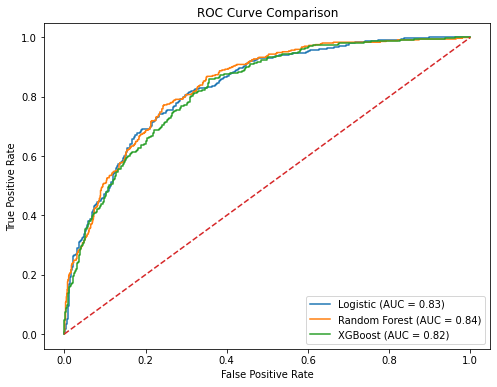

In [100]:
# ROC Values
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

#AUC score
auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

print(auc_log)
print(auc_rf)
print(auc_xgb)

# print(roc_auc_score(y_test, y_proba_log) == auc_log)
# We can use above syntax also to find the auc score inplace of auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize =(8,6))
plt.plot(fpr_log, tpr_log, label = f"Logistic (AUC = {auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label = f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label = f"XGBoost (AUC = {auc_xgb:.2f})")

plt.plot([0,1], [0,1], linestyle = '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()